In [17]:
import os
import re
import json
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis

# sklearn: preprocessing, metrics, classical ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Classical ML models
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.svm import SVR, SVC
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.pipeline import Pipeline

# PyTorch for deep learning models
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [18]:
# %% [code]
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cpu


In [19]:
# %% [code]
# Paths
# Adjust this based on where your notebook is located.

PROJECT_ROOT = Path("../../").resolve()

# If StudentGrades.txt and participant folders are next to notebook:
DATA_ROOT = PROJECT_ROOT / 'Data'

GRADES_PATH = DATA_ROOT / "StudentGrades.txt"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("GRADES_PATH exists:", GRADES_PATH.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)


PROJECT_ROOT: /Users/parsa/Desktop/projects/github/Attention-Based-Stress-Prediction-Wearables
DATA_ROOT: /Users/parsa/Desktop/projects/github/Attention-Based-Stress-Prediction-Wearables/Data
GRADES_PATH exists: True
OUTPUT_DIR: /Users/parsa/Desktop/projects/github/Attention-Based-Stress-Prediction-Wearables/outputs


In [20]:
# Global config dictionary
CONFIG = {
    "seed": SEED,
    "device": str(DEVICE),
    "window_size_seconds": 60,
    "step_size_seconds": 30,
    "test_size": 0.20,
    "val_size": 0.25,
    "batch_size": 16,
    "learning_rate": 1e-3,
    "epochs": 100,
    "target_exam": "FINAL",   # later can be MIDTERM 1 / MIDTERM 2 / FINAL
    "task_type": "regression" # later can be changed to classification
}

CONFIG


{'seed': 42,
 'device': 'cpu',
 'window_size_seconds': 60,
 'step_size_seconds': 30,
 'test_size': 0.2,
 'val_size': 0.25,
 'batch_size': 16,
 'learning_rate': 0.001,
 'epochs': 100,
 'target_exam': 'FINAL',
 'task_type': 'regression'}

### Step 2 — Load and Parse StudentGrades.txt

In [24]:
# %% [code]
def parse_student_grades(file_path):
    """
    Parse StudentGrades.txt with headers like:
        GRADES - MIDTERM 1
        GRADES - MIDTERM 2
        GRADES - FINAL (OUT OF 200)

    and rows like:
        S1  78
        S10 116
    """

    with open(file_path, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    current_exam = None
    records = []

    for line in lines:
        upper_line = line.upper()

        # Detect exam headers
        if "MIDTERM 1" in upper_line:
            current_exam = "MIDTERM 1"
            continue
        elif "MIDTERM 2" in upper_line:
            current_exam = "MIDTERM 2"
            continue
        elif "FINAL" in upper_line:
            current_exam = "FINAL"
            continue

        # Skip separator lines like ------
        if set(line) == {"-"}:
            continue

        # Match student-grade rows
        match = re.match(r"^(S\d+)\s+(\d+(?:\.\d+)?)$", line, flags=re.IGNORECASE)
        if match and current_exam is not None:
            student_id = match.group(1).upper()
            grade = float(match.group(2))
            records.append({
                "student_id": student_id,
                "exam": current_exam,
                "grade": grade
            })

    df_long = pd.DataFrame(records)

    if df_long.empty:
        raise ValueError("No grade records were parsed. Please inspect StudentGrades.txt format.")

    return df_long


In [25]:
# %% [code]
grades_long_df = parse_student_grades(GRADES_PATH)
grades_long_df


,student_id,exam,grade
0,S1,MIDTERM 1,78.0
1,S2,MIDTERM 1,82.0
2,S3,MIDTERM 1,77.0
3,S4,MIDTERM 1,75.0
4,S5,MIDTERM 1,67.0
5,S6,MIDTERM 1,71.0
6,S7,MIDTERM 1,64.0
7,S8,MIDTERM 1,92.0
8,S9,MIDTERM 1,80.0
9,S10,MIDTERM 1,89.0


In [26]:
# %% [code]
print("Shape:", grades_long_df.shape)
print("Unique exams:", grades_long_df["exam"].unique())
print("Unique students:", sorted(grades_long_df["student_id"].unique()))


Shape: (30, 3)
Unique exams: <StringArray>
['MIDTERM 1', 'MIDTERM 2', 'FINAL']
Length: 3, dtype: str
Unique students: ['S1', 'S10', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']


In [27]:
# %% [code]
grades_wide_df = grades_long_df.pivot(index="student_id", columns="exam", values="grade").reset_index()

grades_wide_df = grades_wide_df.rename(columns={
    "MIDTERM 1": "midterm_1",
    "MIDTERM 2": "midterm_2",
    "FINAL": "final"
})

# Sort students numerically: S1, S2, ..., S10
grades_wide_df["student_num"] = grades_wide_df["student_id"].str.extract(r"(\d+)").astype(int)
grades_wide_df = grades_wide_df.sort_values("student_num").drop(columns="student_num").reset_index(drop=True)

grades_wide_df


exam,student_id,final,midterm_1,midterm_2
0,S1,182.0,78.0,82.0
1,S2,180.0,82.0,85.0
2,S3,188.0,77.0,90.0
3,S4,149.0,75.0,77.0
4,S5,157.0,67.0,77.0
5,S6,175.0,71.0,64.0
6,S7,110.0,64.0,33.0
7,S8,184.0,92.0,88.0
8,S9,126.0,80.0,39.0
9,S10,116.0,89.0,64.0


In [28]:
# %% [code]
print("Missing values per column:")
print(grades_wide_df.isna().sum())

print("\nSummary statistics:")
display(grades_wide_df[["midterm_1", "midterm_2", "final"]].describe())


Missing values per column:
exam
student_id    0
final         0
midterm_1     0
midterm_2     0
dtype: int64

Summary statistics:


exam,midterm_1,midterm_2,final
count,10.000000,10.000000,10.000000
mean,77.500000,69.900000,156.700000
std,8.885069,19.980268,29.966834
min,64.000000,33.000000,110.000000
25%,72.000000,64.000000,131.750000
50%,77.500000,77.000000,166.000000
75%,81.500000,84.250000,181.500000
max,92.000000,90.000000,188.000000


In [29]:
# Save parsed tables
grades_long_df.to_csv(OUTPUT_DIR / "grades_long.csv", index=False)
grades_wide_df.to_csv(OUTPUT_DIR / "grades_wide.csv", index=False)

print("Saved files:")
print(OUTPUT_DIR / "grades_long.csv")
print(OUTPUT_DIR / "grades_wide.csv")


Saved files:
/Users/parsa/Desktop/projects/github/Attention-Based-Stress-Prediction-Wearables/outputs/grades_long.csv
/Users/parsa/Desktop/projects/github/Attention-Based-Stress-Prediction-Wearables/outputs/grades_wide.csv


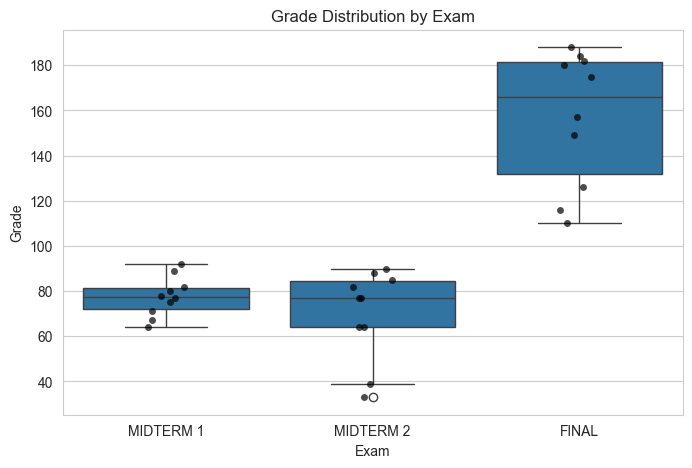

In [30]:
# %% [code]
plt.figure(figsize=(8, 5))
sns.boxplot(data=grades_long_df, x="exam", y="grade")
sns.stripplot(data=grades_long_df, x="exam", y="grade", color="black", alpha=0.7)
plt.title("Grade Distribution by Exam")
plt.xlabel("Exam")
plt.ylabel("Grade")
plt.show()


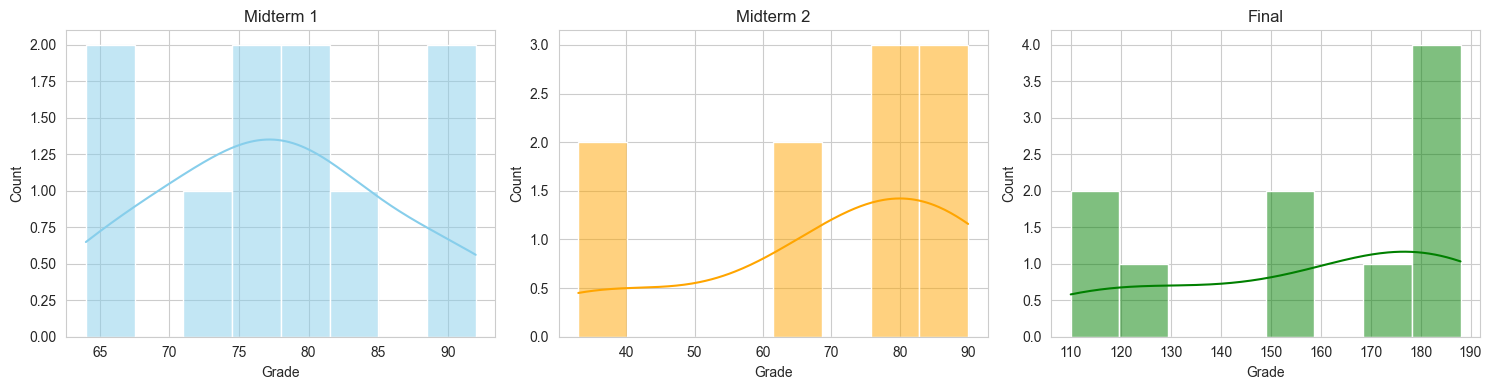

In [31]:
# %% [code]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(grades_wide_df["midterm_1"], bins=8, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Midterm 1")

sns.histplot(grades_wide_df["midterm_2"], bins=8, kde=True, ax=axes[1], color="orange")
axes[1].set_title("Midterm 2")

sns.histplot(grades_wide_df["final"], bins=8, kde=True, ax=axes[2], color="green")
axes[2].set_title("Final")

for ax in axes:
    ax.set_xlabel("Grade")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


In [32]:
# %% [code]
# Optional: create a binary target from final grade using median split
final_median = grades_wide_df["final"].median()
grades_wide_df["final_binary"] = (grades_wide_df["final"] >= final_median).astype(int)

print("Median final grade:", final_median)
grades_wide_df[["student_id", "final", "final_binary"]]


Median final grade: 166.0


exam,student_id,final,final_binary
0,S1,182.0,1
1,S2,180.0,1
2,S3,188.0,1
3,S4,149.0,0
4,S5,157.0,0
5,S6,175.0,1
6,S7,110.0,0
7,S8,184.0,1
8,S9,126.0,0
9,S10,116.0,0


### Step 3 — Discover Student Folders and Inspect

In [34]:
# %% [code]
def find_student_folders(data_root):
    student_dirs = []
    for item in data_root.iterdir():
        if item.is_dir() and re.match(r"^S\d+$", item.name, flags=re.IGNORECASE):
            student_dirs.append(item)
    return sorted(student_dirs, key=lambda x: int(re.findall(r"\d+", x.name)[0]))


In [35]:
# %% [code]
student_dirs = find_student_folders(DATA_ROOT)
print("Number of student folders found:", len(student_dirs))
print([p.name for p in student_dirs])


Number of student folders found: 10
['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10']


In [36]:
# %% [code]
EXPECTED_EXAMS = ["Final", "Midterm 1", "Midterm 2"]

for student_dir in student_dirs:
    print(f"\n{student_dir.name}")
    subfolders = [p.name for p in student_dir.iterdir() if p.is_dir()]
    print(" Exam folders:", subfolders)



S1
 Exam folders: ['Midterm 2', 'Midterm 1', 'Final']

S2
 Exam folders: ['Midterm 2', 'Midterm 1', 'Final']

S3
 Exam folders: ['Midterm 2', 'Midterm 1', 'Final']

S4
 Exam folders: ['Midterm 2', 'Midterm 1', 'Final']

S5
 Exam folders: ['Midterm 2', 'Midterm 1', 'Final']

S6
 Exam folders: ['Midterm 2', 'Midterm 1', 'Final']

S7
 Exam folders: ['Midterm 2', 'Midterm 1', 'Final']

S8
 Exam folders: ['Midterm 2', 'Midterm 1', 'Final']

S9
 Exam folders: ['Midterm 2', 'Midterm 1', 'Final']

S10
 Exam folders: ['Midterm 2', 'Midterm 1', 'Final']


In [37]:
# %% [code]
EXPECTED_FILES = [
    "ACC.csv",
    "BVP.csv",
    "EDA.csv",
    "HR.csv",
    "IBI.csv",
    "TEMP.csv",
    "tags.csv",
    "info.txt"
]

structure_records = []

for student_dir in student_dirs:
    for exam_name in EXPECTED_EXAMS:
        exam_dir = student_dir / exam_name
        row = {
            "student_id": student_dir.name,
            "exam_folder": exam_name,
            "exists": exam_dir.exists()
        }

        for fname in EXPECTED_FILES:
            row[fname] = (exam_dir / fname).exists() if exam_dir.exists() else False

        structure_records.append(row)

structure_df = pd.DataFrame(structure_records)
structure_df


,student_id,exam_folder,exists,ACC.csv,BVP.csv,EDA.csv,HR.csv,IBI.csv,TEMP.csv,tags.csv,info.txt
0,S1,Final,True,True,True,True,True,True,True,True,True
1,S1,Midterm 1,True,True,True,True,True,True,True,True,True
2,S1,Midterm 2,True,True,True,True,True,True,True,True,True
3,S2,Final,True,True,True,True,True,True,True,True,True
4,S2,Midterm 1,True,True,True,True,True,True,True,True,True
5,S2,Midterm 2,True,True,True,True,True,True,True,True,True
6,S3,Final,True,True,True,True,True,True,True,True,True
7,S3,Midterm 1,True,True,True,True,True,True,True,True,True
8,S3,Midterm 2,True,True,True,True,True,True,True,True,True
9,S4,Final,True,True,True,True,True,True,True,True,True


In [38]:
# %% [code]
# Summary: how many session folders contain each file?
summary_cols = ["exists"] + EXPECTED_FILES
structure_summary = structure_df[summary_cols].sum().to_frame("count_present")
structure_summary["out_of"] = len(structure_df)
structure_summary


,count_present,out_of
exists,30,30
ACC.csv,30,30
BVP.csv,30,30
EDA.csv,30,30
HR.csv,30,30
IBI.csv,30,30
TEMP.csv,30,30
tags.csv,30,30
info.txt,30,30


In [40]:
# %% [code]
example_dir = DATA_ROOT / "S1" / "Final"
print("Example directory:", example_dir)

if example_dir.exists():
    print("\nFiles inside:")
    for p in sorted(example_dir.iterdir()):
        print("-", p.name)
else:
    print("Example directory not found. Please adjust the path or choose another folder.")


Example directory: /Users/parsa/Desktop/projects/github/Attention-Based-Stress-Prediction-Wearables/Data/S1/Final

Files inside:
- ACC.csv
- BVP.csv
- EDA.csv
- HR.csv
- IBI.csv
- TEMP.csv
- info.txt
- tags.csv


In [41]:
# %% [code]
def preview_text_file(path, n_lines=10):
    print(f"\nPreview: {path}")
    if not path.exists():
        print("File not found.")
        return
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= n_lines:
                break
            print(line.rstrip())


In [42]:
# %% [code]
# Preview a few files from one example folder
for fname in ["ACC.csv", "BVP.csv", "EDA.csv", "HR.csv", "IBI.csv", "TEMP.csv", "tags.csv", "info.txt"]:
    preview_text_file(example_dir / fname, n_lines=8)



Preview: /Users/parsa/Desktop/projects/github/Attention-Based-Stress-Prediction-Wearables/Data/S1/Final/ACC.csv
1544027337.000000, 1544027337.000000, 1544027337.000000
32.000000, 32.000000, 32.000000
-3,65,6
-3,65,6
-3,65,6
-3,65,6
-3,65,6
-3,65,6

Preview: /Users/parsa/Desktop/projects/github/Attention-Based-Stress-Prediction-Wearables/Data/S1/Final/BVP.csv
1544027337.00
64.000000
-0.00
-0.00
-0.00
-0.00
-0.00
-0.00

Preview: /Users/parsa/Desktop/projects/github/Attention-Based-Stress-Prediction-Wearables/Data/S1/Final/EDA.csv
1544027337.000000
4.000000
0.000000
0.005125
0.020501
0.021783
0.023064
0.024345

Preview: /Users/parsa/Desktop/projects/github/Attention-Based-Stress-Prediction-Wearables/Data/S1/Final/HR.csv
1544027347.000000
1.000000
116.00
82.50
96.33
86.25
98.60
107.50

Preview: /Users/parsa/Desktop/projects/github/Attention-Based-Stress-Prediction-Wearables/Data/S1/Final/IBI.csv
1544027337.000000, IBI
84.847634,0.468771
85.347657,0.500023
85.722674,0.375017
107.754932,0.4

In [43]:
# %% [code]
def try_read_csv(path, nrows=10):
    print(f"\nTrying pandas read_csv on: {path.name}")
    if not path.exists():
        print("File not found.")
        return None
    
    try:
        df = pd.read_csv(path, header=None, nrows=nrows)
        display(df)
        return df
    except Exception as e:
        print("Could not read with default pd.read_csv:", e)
        return None


In [44]:
# %% [code]
_ = try_read_csv(example_dir / "ACC.csv")
_ = try_read_csv(example_dir / "BVP.csv")
_ = try_read_csv(example_dir / "EDA.csv")
_ = try_read_csv(example_dir / "HR.csv")
_ = try_read_csv(example_dir / "IBI.csv")
_ = try_read_csv(example_dir / "TEMP.csv")
_ = try_read_csv(example_dir / "tags.csv")



Trying pandas read_csv on: ACC.csv


,0,1,2
0,1.544027e+09,1.544027e+09,1.544027e+09
1,3.200000e+01,3.200000e+01,3.200000e+01
2,-3.000000e+00,6.500000e+01,6.000000e+00
3,-3.000000e+00,6.500000e+01,6.000000e+00
4,-3.000000e+00,6.500000e+01,6.000000e+00
5,-3.000000e+00,6.500000e+01,6.000000e+00
6,-3.000000e+00,6.500000e+01,6.000000e+00
7,-3.000000e+00,6.500000e+01,6.000000e+00
8,-3.000000e+00,6.500000e+01,6.000000e+00
9,-3.000000e+00,6.500000e+01,6.000000e+00



Trying pandas read_csv on: BVP.csv


,0
0,1.544027e+09
1,6.400000e+01
2,-0.000000e+00
3,-0.000000e+00
4,-0.000000e+00
5,-0.000000e+00
6,-0.000000e+00
7,-0.000000e+00
8,-0.000000e+00
9,-0.000000e+00



Trying pandas read_csv on: EDA.csv


...


Trying pandas read_csv on: IBI.csv


,0,1
0,1.544027e+09,IBI
1,8.484763e+01,0.468771
2,8.534766e+01,0.500023
3,8.572267e+01,0.375017
4,1.077549e+02,0.437520
5,1.082237e+02,0.468771
6,1.086456e+02,0.421894
7,1.091144e+02,0.468771
8,1.095206e+02,0.406269
9,1.099894e+02,0.468771



Trying pandas read_csv on: TEMP.csv


,0
0,1.544027e+09
1,4.000000e+00
2,2.189000e+01
3,2.189000e+01
4,2.189000e+01
5,2.189000e+01
6,2.189000e+01
7,2.189000e+01
8,2.189000e+01
9,2.189000e+01



Trying pandas read_csv on: tags.csv
Could not read with default pd.read_csv: No columns to parse from file


In [45]:
# %% [code]
session_inventory = []

for student_dir in student_dirs:
    student_id = student_dir.name
    
    for exam_folder in EXPECTED_EXAMS:
        exam_dir = student_dir / exam_folder
        if not exam_dir.exists():
            continue
            
        session_inventory.append({
            "student_id": student_id,
            "exam_folder": exam_folder,
            "session_path": str(exam_dir),
            "ACC_exists": (exam_dir / "ACC.csv").exists(),
            "BVP_exists": (exam_dir / "BVP.csv").exists(),
            "EDA_exists": (exam_dir / "EDA.csv").exists(),
            "HR_exists": (exam_dir / "HR.csv").exists(),
            "IBI_exists": (exam_dir / "IBI.csv").exists(),
            "TEMP_exists": (exam_dir / "TEMP.csv").exists(),
            "tags_exists": (exam_dir / "tags.csv").exists(),
            "info_exists": (exam_dir / "info.txt").exists(),
        })

session_inventory_df = pd.DataFrame(session_inventory)
session_inventory_df


,student_id,exam_folder,session_path,ACC_exists,BVP_exists,EDA_exists,HR_exists,IBI_exists,TEMP_exists,tags_exists,info_exists
0,S1,Final,/Users/parsa/Desktop/projects/github/Attention...,True,True,True,True,True,True,True,True
1,S1,Midterm 1,/Users/parsa/Desktop/projects/github/Attention...,True,True,True,True,True,True,True,True
2,S1,Midterm 2,/Users/parsa/Desktop/projects/github/Attention...,True,True,True,True,True,True,True,True
3,S2,Final,/Users/parsa/Desktop/projects/github/Attention...,True,True,True,True,True,True,True,True
4,S2,Midterm 1,/Users/parsa/Desktop/projects/github/Attention...,True,True,True,True,True,True,True,True
5,S2,Midterm 2,/Users/parsa/Desktop/projects/github/Attention...,True,True,True,True,True,True,True,True
6,S3,Final,/Users/parsa/Desktop/projects/github/Attention...,True,True,True,True,True,True,True,True
7,S3,Midterm 1,/Users/parsa/Desktop/projects/github/Attention...,True,True,True,True,True,True,True,True
8,S3,Midterm 2,/Users/parsa/Desktop/projects/github/Attention...,True,True,True,True,True,True,True,True
9,S4,Final,/Users/parsa/Desktop/projects/github/Attention...,True,True,True,True,True,True,True,True


### Step 4 — Build Robust Loaders for Physiological

In [46]:
from datetime import datetime, timezone


In [47]:
def unix_to_datetime(ts):
    """Convert unix timestamp (float) to pandas datetime in UTC."""
    return pd.to_datetime(ts, unit="s", utc=True)

In [48]:
def load_single_channel_signal(file_path, signal_name="signal"):
    """
    Load a regular single-channel Empatica-style signal file.

    Expected format:
    - row 1: start timestamp
    - row 2: sampling rate
    - row 3 onward: samples

    Returns:
        df: DataFrame with columns:
            ['timestamp', 'datetime_utc', signal_name]
        meta: dict with start_time, sample_rate, n_samples
    """
    if not Path(file_path).exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    raw = pd.read_csv(file_path, header=None)

    start_time = float(raw.iloc[0, 0])
    sample_rate = float(raw.iloc[1, 0])

    values = raw.iloc[2:, 0].astype(float).reset_index(drop=True)

    timestamps = start_time + np.arange(len(values)) / sample_rate

    df = pd.DataFrame({
        "timestamp": timestamps,
        "datetime_utc": pd.to_datetime(timestamps, unit="s", utc=True),
        signal_name: values
    })

    meta = {
        "signal_name": signal_name,
        "start_time": start_time,
        "start_datetime_utc": pd.to_datetime(start_time, unit="s", utc=True),
        "sample_rate": sample_rate,
        "n_samples": len(df)
    }

    return df, meta


In [49]:
def load_acc_signal(file_path):
    """
    Load ACC.csv in Empatica-style format.

    Expected format:
    - row 1: start timestamp repeated across 3 columns
    - row 2: sample rate repeated across 3 columns
    - row 3 onward: x, y, z acceleration samples

    Returns:
        df: DataFrame with columns:
            ['timestamp', 'datetime_utc', 'acc_x', 'acc_y', 'acc_z']
        meta: dict
    """
    if not Path(file_path).exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    raw = pd.read_csv(file_path, header=None)

    start_time = float(raw.iloc[0, 0])
    sample_rate = float(raw.iloc[1, 0])

    values = raw.iloc[2:, :3].copy().reset_index(drop=True)
    values.columns = ["acc_x", "acc_y", "acc_z"]

    # Convert comma-based numeric strings if needed
    for col in values.columns:
        values[col] = values[col].astype(str).str.replace(",", ".", regex=False).astype(float)

    timestamps = start_time + np.arange(len(values)) / sample_rate

    df = pd.DataFrame({
        "timestamp": timestamps,
        "datetime_utc": pd.to_datetime(timestamps, unit="s", utc=True),
        "acc_x": values["acc_x"],
        "acc_y": values["acc_y"],
        "acc_z": values["acc_z"],
    })

    meta = {
        "signal_name": "ACC",
        "start_time": start_time,
        "start_datetime_utc": pd.to_datetime(start_time, unit="s", utc=True),
        "sample_rate": sample_rate,
        "n_samples": len(df)
    }

    return df, meta


In [50]:
# %% [code]
def load_ibi_signal(file_path):
    """
    Load IBI.csv.

    Expected format:
    - first row: [session_start_timestamp, 'IBI']
    - remaining rows:
        col 0 = offset in seconds from session start
        col 1 = IBI duration in seconds

    Returns:
        df: DataFrame with columns:
            ['offset_seconds', 'timestamp', 'datetime_utc', 'ibi']
        meta: dict
    """
    if not Path(file_path).exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    raw = pd.read_csv(file_path, header=None)

    session_start = float(raw.iloc[0, 0])

    values = raw.iloc[1:, :2].copy().reset_index(drop=True)
    values.columns = ["offset_seconds", "ibi"]

    for col in values.columns:
        values[col] = values[col].astype(str).str.replace(",", ".", regex=False).astype(float)

    timestamps = session_start + values["offset_seconds"].values

    df = pd.DataFrame({
        "offset_seconds": values["offset_seconds"],
        "timestamp": timestamps,
        "datetime_utc": pd.to_datetime(timestamps, unit="s", utc=True),
        "ibi": values["ibi"]
    })

    meta = {
        "signal_name": "IBI",
        "session_start_time": session_start,
        "session_start_datetime_utc": pd.to_datetime(session_start, unit="s", utc=True),
        "n_samples": len(df)
    }

    return df, meta


In [51]:
# %% [code]
def load_tags(file_path):
    """
    Load tags.csv if present.

    Returns:
        df: DataFrame with columns ['timestamp', 'datetime_utc']
        meta: dict
    """
    path = Path(file_path)

    if not path.exists():
        return pd.DataFrame(columns=["timestamp", "datetime_utc"]), {
            "signal_name": "tags",
            "exists": False,
            "n_samples": 0
        }

    if path.stat().st_size == 0:
        return pd.DataFrame(columns=["timestamp", "datetime_utc"]), {
            "signal_name": "tags",
            "exists": True,
            "empty": True,
            "n_samples": 0
        }

    raw = pd.read_csv(path, header=None)
    timestamps = raw.iloc[:, 0].astype(float).values

    df = pd.DataFrame({
        "timestamp": timestamps,
        "datetime_utc": pd.to_datetime(timestamps, unit="s", utc=True)
    })

    meta = {
        "signal_name": "tags",
        "exists": True,
        "empty": False,
        "n_samples": len(df)
    }

    return df, meta


In [52]:
# %% [code]
def load_session_signals(session_dir):
    """
    Load all available signals for one session directory.

    Parameters
    ----------
    session_dir : str or Path
        Example: DATA_ROOT / 'S1' / 'Final'

    Returns
    -------
    session_data : dict
        Keys:
            'ACC', 'BVP', 'EDA', 'HR', 'TEMP', 'IBI', 'tags'
        Each value is a DataFrame or None if unavailable.
    session_meta : dict
        Metadata for each modality.
    """
    session_dir = Path(session_dir)

    session_data = {}
    session_meta = {}

    # ACC
    acc_path = session_dir / "ACC.csv"
    if acc_path.exists():
        try:
            session_data["ACC"], session_meta["ACC"] = load_acc_signal(acc_path)
        except Exception as e:
            session_data["ACC"] = None
            session_meta["ACC"] = {"error": str(e)}

    # Single-channel signals
    for fname, key in [
        ("BVP.csv", "BVP"),
        ("EDA.csv", "EDA"),
        ("HR.csv", "HR"),
        ("TEMP.csv", "TEMP"),
    ]:
        path = session_dir / fname
        if path.exists():
            try:
                session_data[key], session_meta[key] = load_single_channel_signal(path, signal_name=key.lower())
            except Exception as e:
                session_data[key] = None
                session_meta[key] = {"error": str(e)}
        else:
            session_data[key] = None
            session_meta[key] = {"missing": True}

    # IBI
    ibi_path = session_dir / "IBI.csv"
    if ibi_path.exists():
        try:
            session_data["IBI"], session_meta["IBI"] = load_ibi_signal(ibi_path)
        except Exception as e:
            session_data["IBI"] = None
            session_meta["IBI"] = {"error": str(e)}
    else:
        session_data["IBI"] = None
        session_meta["IBI"] = {"missing": True}

    # tags
    tags_path = session_dir / "tags.csv"
    session_data["tags"], session_meta["tags"] = load_tags(tags_path)

    return session_data, session_meta


In [53]:
# %% [code]
example_session_dir = DATA_ROOT / "S1" / "Final"

session_data, session_meta = load_session_signals(example_session_dir)

print("Loaded modalities:")
for k, v in session_data.items():
    if v is None:
        print(f"- {k}: None")
    else:
        print(f"- {k}: shape={v.shape}")

print("\nMetadata:")
for k, v in session_meta.items():
    print(f"{k}: {v}")


Loaded modalities:
- ACC: shape=(748686, 5)
- BVP: shape=(1497375, 3)
- EDA: shape=(93582, 3)
- HR: shape=(23387, 3)
- TEMP: shape=(93584, 3)
- IBI: shape=(2168, 4)
- tags: shape=(0, 2)

Metadata:
ACC: {'signal_name': 'ACC', 'start_time': 1544027337.0, 'start_datetime_utc': Timestamp('2018-12-05 16:28:57+0000', tz='UTC'), 'sample_rate': 32.0, 'n_samples': 748686}
BVP: {'signal_name': 'bvp', 'start_time': 1544027337.0, 'start_datetime_utc': Timestamp('2018-12-05 16:28:57+0000', tz='UTC'), 'sample_rate': 64.0, 'n_samples': 1497375}
EDA: {'signal_name': 'eda', 'start_time': 1544027337.0, 'start_datetime_utc': Timestamp('2018-12-05 16:28:57+0000', tz='UTC'), 'sample_rate': 4.0, 'n_samples': 93582}
HR: {'signal_name': 'hr', 'start_time': 1544027347.0, 'start_datetime_utc': Timestamp('2018-12-05 16:29:07+0000', tz='UTC'), 'sample_rate': 1.0, 'n_samples': 23387}
TEMP: {'signal_name': 'temp', 'start_time': 1544027337.0, 'start_datetime_utc': Timestamp('2018-12-05 16:28:57+0000', tz='UTC'), 'sa

In [54]:
# %% [code]
for modality in ["ACC", "BVP", "EDA", "HR", "TEMP", "IBI", "tags"]:
    print(f"\n===== {modality} =====")
    df = session_data.get(modality)
    if df is None:
        print("Not loaded.")
    else:
        display(df.head())



===== ACC =====


,timestamp,datetime_utc,acc_x,acc_y,acc_z
0,1.544027e+09,2018-12-05 16:28:57+00:00,-3.0,65.0,6.0
1,1.544027e+09,2018-12-05 16:28:57.031250+00:00,-3.0,65.0,6.0
2,1.544027e+09,2018-12-05 16:28:57.062500+00:00,-3.0,65.0,6.0
3,1.544027e+09,2018-12-05 16:28:57.093750+00:00,-3.0,65.0,6.0
4,1.544027e+09,2018-12-05 16:28:57.125000+00:00,-3.0,65.0,6.0



===== BVP =====


,timestamp,datetime_utc,bvp
0,1.544027e+09,2018-12-05 16:28:57+00:00,-0.0
1,1.544027e+09,2018-12-05 16:28:57.015625+00:00,-0.0
2,1.544027e+09,2018-12-05 16:28:57.031250+00:00,-0.0
3,1.544027e+09,2018-12-05 16:28:57.046875+00:00,-0.0
4,1.544027e+09,2018-12-05 16:28:57.062500+00:00,-0.0



===== EDA =====


...

,timestamp,datetime_utc,temp
0,1.544027e+09,2018-12-05 16:28:57+00:00,21.89
1,1.544027e+09,2018-12-05 16:28:57.250000+00:00,21.89
2,1.544027e+09,2018-12-05 16:28:57.500000+00:00,21.89
3,1.544027e+09,2018-12-05 16:28:57.750000+00:00,21.89
4,1.544027e+09,2018-12-05 16:28:58+00:00,21.89



===== IBI =====


,offset_seconds,timestamp,datetime_utc,ibi
0,84.847634,1.544027e+09,2018-12-05 16:30:21.847634077+00:00,0.468771
1,85.347657,1.544027e+09,2018-12-05 16:30:22.347656965+00:00,0.500023
2,85.722674,1.544027e+09,2018-12-05 16:30:22.722673893+00:00,0.375017
3,107.754932,1.544027e+09,2018-12-05 16:30:44.754931927+00:00,0.437520
4,108.223704,1.544027e+09,2018-12-05 16:30:45.223704100+00:00,0.468771



===== tags =====


,timestamp,datetime_utc


In [55]:
# %% [code]
def summarize_loaded_signal(df, signal_name):
    if df is None or len(df) == 0:
        return {
            "signal": signal_name,
            "n_samples": 0,
            "start_time": None,
            "end_time": None,
            "duration_seconds": 0
        }

    start_time = df["timestamp"].min()
    end_time = df["timestamp"].max()

    return {
        "signal": signal_name,
        "n_samples": len(df),
        "start_time": start_time,
        "end_time": end_time,
        "duration_seconds": end_time - start_time
    }


In [56]:
# %% [code]
signal_summary = pd.DataFrame([
    summarize_loaded_signal(session_data.get("ACC"), "ACC"),
    summarize_loaded_signal(session_data.get("BVP"), "BVP"),
    summarize_loaded_signal(session_data.get("EDA"), "EDA"),
    summarize_loaded_signal(session_data.get("HR"), "HR"),
    summarize_loaded_signal(session_data.get("TEMP"), "TEMP"),
    summarize_loaded_signal(session_data.get("IBI"), "IBI"),
    summarize_loaded_signal(session_data.get("tags"), "tags"),
])

signal_summary


,signal,n_samples,start_time,end_time,duration_seconds
0,ACC,748686,1.544027e+09,1.544051e+09,23396.406250
1,BVP,1497375,1.544027e+09,1.544051e+09,23396.468750
2,EDA,93582,1.544027e+09,1.544051e+09,23395.250000
3,HR,23387,1.544027e+09,1.544051e+09,23386.000000
4,TEMP,93584,1.544027e+09,1.544051e+09,23395.750000
5,IBI,2168,1.544027e+09,1.544048e+09,20709.369834
6,tags,0,NaN,NaN,0.000000


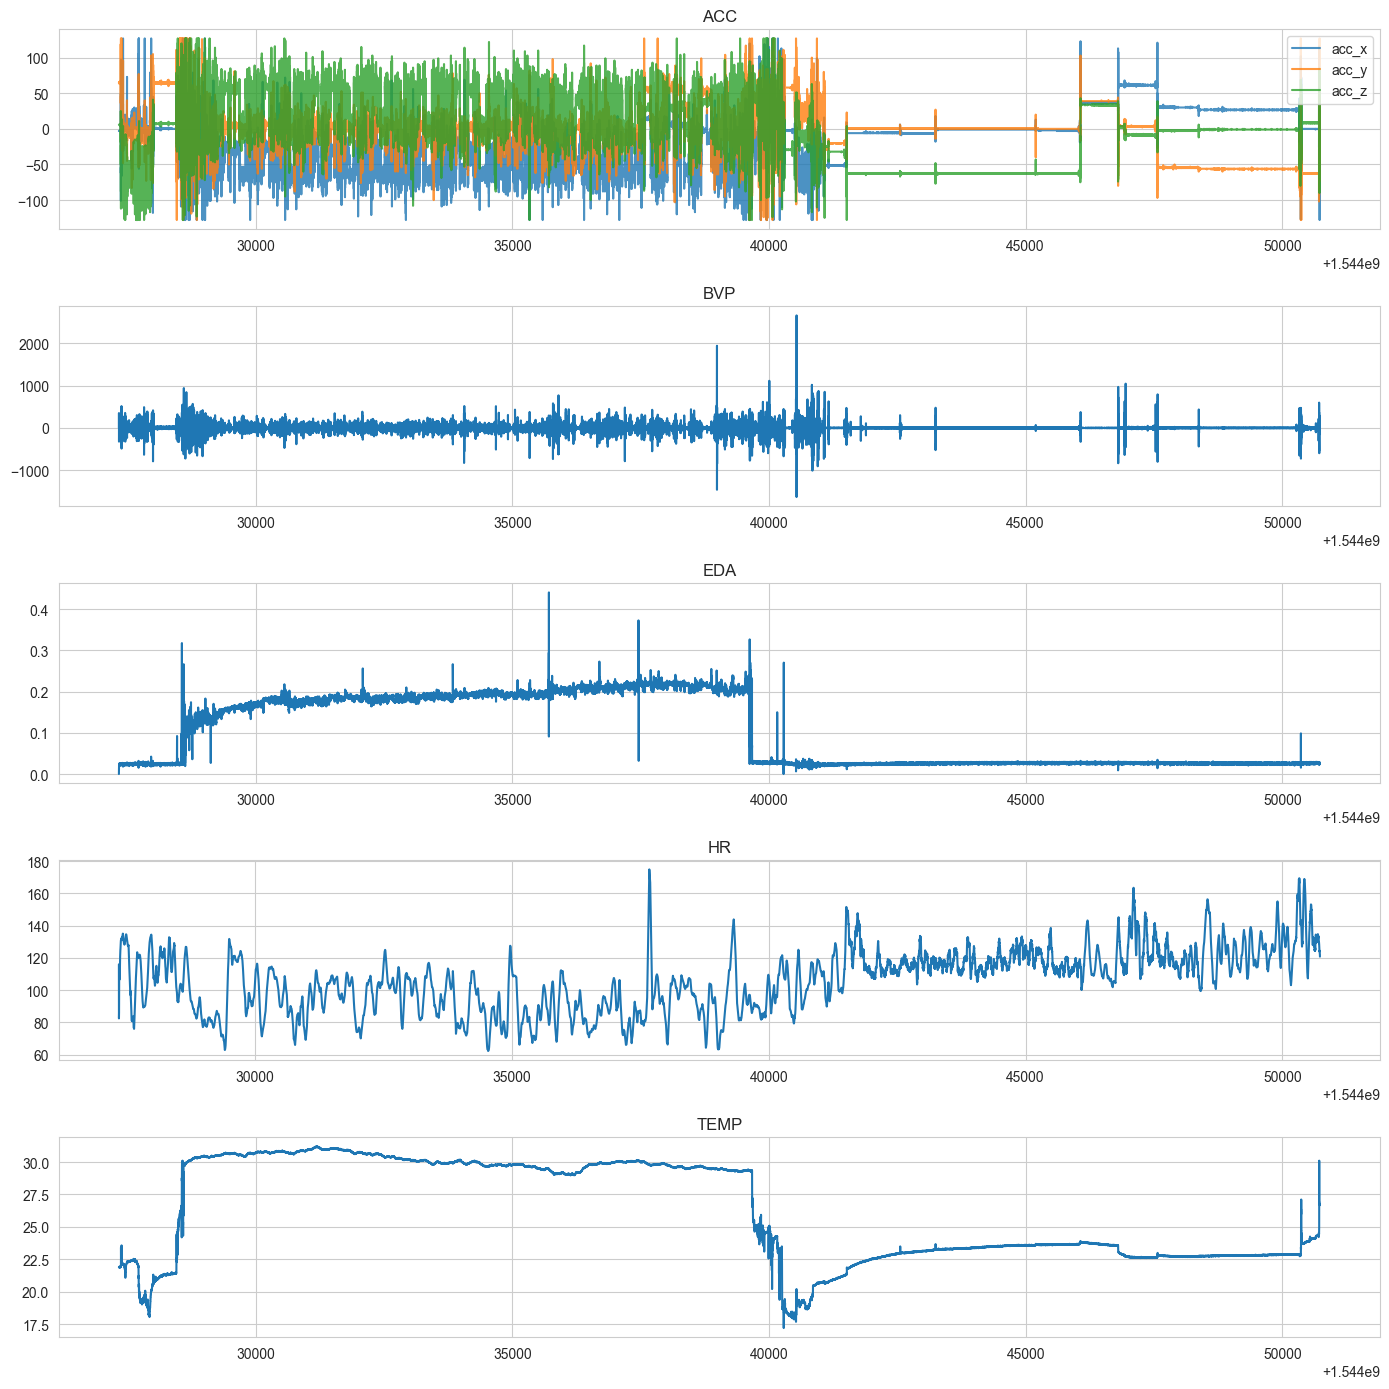

In [57]:
# %% [code]
fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=False)

if session_data["ACC"] is not None:
    axes[0].plot(session_data["ACC"]["timestamp"], session_data["ACC"]["acc_x"], label="acc_x", alpha=0.8)
    axes[0].plot(session_data["ACC"]["timestamp"], session_data["ACC"]["acc_y"], label="acc_y", alpha=0.8)
    axes[0].plot(session_data["ACC"]["timestamp"], session_data["ACC"]["acc_z"], label="acc_z", alpha=0.8)
    axes[0].set_title("ACC")
    axes[0].legend()

if session_data["BVP"] is not None:
    axes[1].plot(session_data["BVP"]["timestamp"], session_data["BVP"]["bvp"])
    axes[1].set_title("BVP")

if session_data["EDA"] is not None:
    axes[2].plot(session_data["EDA"]["timestamp"], session_data["EDA"]["eda"])
    axes[2].set_title("EDA")

if session_data["HR"] is not None:
    axes[3].plot(session_data["HR"]["timestamp"], session_data["HR"]["hr"])
    axes[3].set_title("HR")

if session_data["TEMP"] is not None:
    axes[4].plot(session_data["TEMP"]["timestamp"], session_data["TEMP"]["temp"])
    axes[4].set_title("TEMP")

plt.tight_layout()
plt.show()


In [58]:
EXAM_FOLDER_TO_LABEL_COL = {
    "Midterm 1": "midterm_1",
    "Midterm 2": "midterm_2",
    "Final": "final"
}


In [59]:
def safe_signal_summary(df, meta, modality_name):
    """
    Return a flat summary dictionary for one loaded modality.
    """
    summary = {
        f"{modality_name}_loaded": df is not None,
        f"{modality_name}_n_samples": 0,
        f"{modality_name}_sample_rate": np.nan,
        f"{modality_name}_duration_seconds": np.nan,
        f"{modality_name}_start_timestamp": np.nan,
        f"{modality_name}_end_timestamp": np.nan,
        f"{modality_name}_error": None
    }

    if meta is not None and isinstance(meta, dict) and "error" in meta:
        summary[f"{modality_name}_error"] = meta["error"]

    if df is None or len(df) == 0:
        return summary

    summary[f"{modality_name}_n_samples"] = len(df)

    if "sample_rate" in meta:
        summary[f"{modality_name}_sample_rate"] = meta["sample_rate"]

    if "timestamp" in df.columns:
        start_ts = df["timestamp"].min()
        end_ts = df["timestamp"].max()
        summary[f"{modality_name}_start_timestamp"] = start_ts
        summary[f"{modality_name}_end_timestamp"] = end_ts
        summary[f"{modality_name}_duration_seconds"] = end_ts - start_ts

    return summary


In [60]:
def get_session_grade(student_id, exam_folder, grades_df):
    """
    Get the numeric grade for one student-session.
    """
    label_col = EXAM_FOLDER_TO_LABEL_COL[exam_folder]
    row = grades_df.loc[grades_df["student_id"] == student_id]

    if row.empty:
        return np.nan

    return row.iloc[0][label_col]


In [61]:
def build_exam_median_thresholds(grades_long_df):
    """
    Compute median grade for each exam type using grades_long_df.
    """
    exam_map = {
        "MIDTERM 1": "Midterm 1",
        "MIDTERM 2": "Midterm 2",
        "FINAL": "Final"
    }

    tmp = grades_long_df.copy()
    tmp["exam_folder"] = tmp["exam"].map(exam_map)

    thresholds = tmp.groupby("exam_folder")["grade"].median().to_dict()
    return thresholds


In [62]:
exam_median_thresholds = build_exam_median_thresholds(grades_long_df)
exam_median_thresholds


{'Final': 166.0, 'Midterm 1': 77.5, 'Midterm 2': 77.0}

In [63]:
def get_binary_session_grade(student_id, exam_folder, grades_df, thresholds):
    """
    Create a binary label using median split within each exam type.
    """
    grade = get_session_grade(student_id, exam_folder, grades_df)

    if pd.isna(grade):
        return np.nan

    threshold = thresholds.get(exam_folder, np.nan)
    if pd.isna(threshold):
        return np.nan

    return int(grade >= threshold)


In [64]:
master_rows = []

for student_dir in student_dirs:
    student_id = student_dir.name

    for exam_folder in EXPECTED_EXAMS:
        session_dir = student_dir / exam_folder

        row = {
            "student_id": student_id,
            "exam_folder": exam_folder,
            "session_path": str(session_dir),
            "session_exists": session_dir.exists(),
        }

        if not session_dir.exists():
            # still keep the row for transparency
            row["grade"] = get_session_grade(student_id, exam_folder, grades_wide_df)
            row["grade_binary"] = get_binary_session_grade(
                student_id, exam_folder, grades_wide_df, exam_median_thresholds
            )
            master_rows.append(row)
            continue

        session_data, session_meta = load_session_signals(session_dir)

        # Add modality summaries
        for modality in ["ACC", "BVP", "EDA", "HR", "TEMP", "IBI", "tags"]:
            mod_df = session_data.get(modality)
            mod_meta = session_meta.get(modality, {})
            row.update(safe_signal_summary(mod_df, mod_meta, modality))

        # Add labels
        row["grade"] = get_session_grade(student_id, exam_folder, grades_wide_df)
        row["grade_binary"] = get_binary_session_grade(
            student_id, exam_folder, grades_wide_df, exam_median_thresholds
        )

        master_rows.append(row)

master_session_df = pd.DataFrame(master_rows)
master_session_df


,student_id,exam_folder,session_path,session_exists,ACC_loaded,ACC_n_samples,ACC_sample_rate,ACC_duration_seconds,ACC_start_timestamp,ACC_end_timestamp,...,IBI_error,tags_loaded,tags_n_samples,tags_sample_rate,tags_duration_seconds,tags_start_timestamp,tags_end_timestamp,tags_error,grade,grade_binary
0,S1,Final,/Users/parsa/Desktop/projects/github/Attention...,True,True,748686,32.0,23396.40625,1.544027e+09,1.544051e+09,...,None,True,0,NaN,NaN,NaN,NaN,None,182.0,1
1,S1,Midterm 1,/Users/parsa/Desktop/projects/github/Attention...,True,True,357702,32.0,11178.15625,1.539435e+09,1.539447e+09,...,None,True,2,NaN,546.55,1.539446e+09,1.539447e+09,None,78.0,1
2,S1,Midterm 2,/Users/parsa/Desktop/projects/github/Attention...,True,True,356376,32.0,11136.71875,1.541860e+09,1.541871e+09,...,None,True,0,NaN,NaN,NaN,NaN,None,82.0,1
3,S2,Final,/Users/parsa/Desktop/projects/github/Attention...,True,True,810780,32.0,25336.84375,1.544027e+09,1.544053e+09,...,None,True,0,NaN,NaN,NaN,NaN,None,180.0,1
4,S2,Midterm 1,/Users/parsa/Desktop/projects/github/Attention...,True,True,383496,32.0,11984.21875,1.539435e+09,1.539447e+09,...,None,True,2,NaN,1316.85,1.539446e+09,1.539447e+09,None,82.0,1
5,S2,Midterm 2,/Users/parsa/Desktop/projects/github/Attention...,True,True,444318,32.0,13884.90625,1.541859e+09,1.541873e+09,...,None,True,2,NaN,1.37,1.541867e+09,1.541867e+09,None,85.0,1
6,S3,Final,/Users/parsa/Desktop/projects/github/Attention...,True,True,826308,32.0,25822.09375,1.544027e+09,1.544053e+09,...,None,True,0,NaN,NaN,NaN,NaN,None,188.0,1
7,S3,Midterm 1,/Users/parsa/Desktop/projects/github/Attention...,True,True,390816,32.0,12212.96875,1.539435e+09,1.539448e+09,...,None,True,2,NaN,1621.51,1.539446e+09,1.539448e+09,None,77.0,0
8,S3,Midterm 2,/Users/parsa/Desktop/projects/github/Attention...,True,True,327840,32.0,10244.96875,1.541859e+09,1.541870e+09,...,None,True,0,NaN,NaN,NaN,NaN,None,90.0,1
9,S4,Final,/Users/parsa/Desktop/projects/github/Attention...,True,True,509334,32.0,15916.65625,1.544027e+09,1.544043e+09,...,None,True,0,NaN,NaN,NaN,NaN,None,149.0,0


In [65]:
print("Master table shape:", master_session_df.shape)
print("Unique students:", master_session_df["student_id"].nunique())
print("Exam folders:", master_session_df["exam_folder"].unique())

display(master_session_df.head())


Master table shape: (30, 55)
Unique students: 10
Exam folders: <StringArray>
['Final', 'Midterm 1', 'Midterm 2']
Length: 3, dtype: str


,student_id,exam_folder,session_path,session_exists,ACC_loaded,ACC_n_samples,ACC_sample_rate,ACC_duration_seconds,ACC_start_timestamp,ACC_end_timestamp,...,IBI_error,tags_loaded,tags_n_samples,tags_sample_rate,tags_duration_seconds,tags_start_timestamp,tags_end_timestamp,tags_error,grade,grade_binary
0,S1,Final,/Users/parsa/Desktop/projects/github/Attention...,True,True,748686,32.0,23396.40625,1.544027e+09,1.544051e+09,...,None,True,0,NaN,NaN,NaN,NaN,None,182.0,1
1,S1,Midterm 1,/Users/parsa/Desktop/projects/github/Attention...,True,True,357702,32.0,11178.15625,1.539435e+09,1.539447e+09,...,None,True,2,NaN,546.55,1.539446e+09,1.539447e+09,None,78.0,1
2,S1,Midterm 2,/Users/parsa/Desktop/projects/github/Attention...,True,True,356376,32.0,11136.71875,1.541860e+09,1.541871e+09,...,None,True,0,NaN,NaN,NaN,NaN,None,82.0,1
3,S2,Final,/Users/parsa/Desktop/projects/github/Attention...,True,True,810780,32.0,25336.84375,1.544027e+09,1.544053e+09,...,None,True,0,NaN,NaN,NaN,NaN,None,180.0,1
4,S2,Midterm 1,/Users/parsa/Desktop/projects/github/Attention...,True,True,383496,32.0,11984.21875,1.539435e+09,1.539447e+09,...,None,True,2,NaN,1316.85,1.539446e+09,1.539447e+09,None,82.0,1


In [66]:
print("Session existence:")
display(master_session_df["session_exists"].value_counts(dropna=False))

print("\nMissing grades:")
display(master_session_df["grade"].isna().value_counts())

print("\nRows per exam:")
display(master_session_df["exam_folder"].value_counts())


Session existence:


session_exists
True    30
Name: count, dtype: int64


Missing grades:


grade
False    30
Name: count, dtype: int64


Rows per exam:


exam_folder
Final        10
Midterm 1    10
Midterm 2    10
Name: count, dtype: int64

In [67]:
coverage_cols = [f"{m}_loaded" for m in ["ACC", "BVP", "EDA", "HR", "TEMP", "IBI", "tags"]]
coverage_summary = master_session_df[coverage_cols].sum().to_frame("count_loaded")
coverage_summary["total_sessions"] = len(master_session_df)
coverage_summary["coverage_ratio"] = coverage_summary["count_loaded"] / coverage_summary["total_sessions"]
coverage_summary


,count_loaded,total_sessions,coverage_ratio
ACC_loaded,30,30,1.0
BVP_loaded,30,30,1.0
EDA_loaded,30,30,1.0
HR_loaded,30,30,1.0
TEMP_loaded,30,30,1.0
IBI_loaded,30,30,1.0
tags_loaded,30,30,1.0


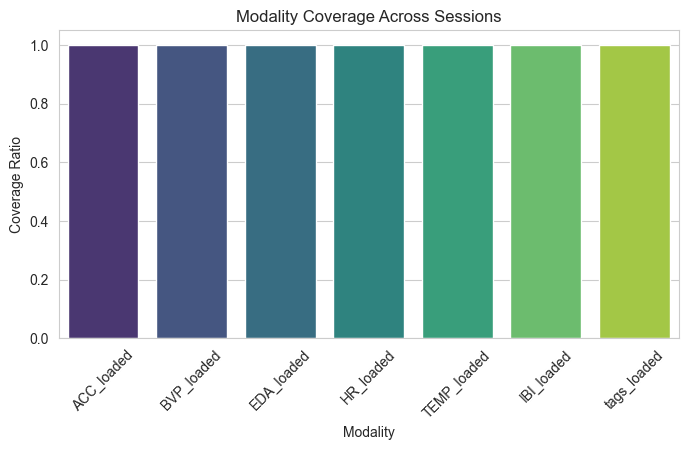

In [68]:
plt.figure(figsize=(8, 4))
sns.barplot(
    x=coverage_summary.index,
    y=coverage_summary["coverage_ratio"],
    palette="viridis"
)
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.title("Modality Coverage Across Sessions")
plt.ylabel("Coverage Ratio")
plt.xlabel("Modality")
plt.show()


In [69]:
sample_rate_cols = [f"{m}_sample_rate" for m in ["ACC", "BVP", "EDA", "HR", "TEMP"]]
master_session_df[sample_rate_cols].describe()


,ACC_sample_rate,BVP_sample_rate,EDA_sample_rate,HR_sample_rate,TEMP_sample_rate
count,30.0,30.0,30.0,30.0,30.0
mean,32.0,64.0,4.0,1.0,4.0
std,0.0,0.0,0.0,0.0,0.0
min,32.0,64.0,4.0,1.0,4.0
25%,32.0,64.0,4.0,1.0,4.0
50%,32.0,64.0,4.0,1.0,4.0
75%,32.0,64.0,4.0,1.0,4.0
max,32.0,64.0,4.0,1.0,4.0


In [70]:
for col in sample_rate_cols:
    print(f"\n{col}")
    print(master_session_df[col].value_counts(dropna=False).sort_index())



ACC_sample_rate
ACC_sample_rate
32.0    30
Name: count, dtype: int64

BVP_sample_rate
BVP_sample_rate
64.0    30
Name: count, dtype: int64

EDA_sample_rate
EDA_sample_rate
4.0    30
Name: count, dtype: int64

HR_sample_rate
HR_sample_rate
1.0    30
Name: count, dtype: int64

TEMP_sample_rate
TEMP_sample_rate
4.0    30
Name: count, dtype: int64


In [71]:
duration_cols = [f"{m}_duration_seconds" for m in ["ACC", "BVP", "EDA", "HR", "TEMP", "IBI"]]
master_session_df[duration_cols].describe()


,ACC_duration_seconds,BVP_duration_seconds,EDA_duration_seconds,HR_duration_seconds,TEMP_duration_seconds,IBI_duration_seconds
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,14776.300000,14776.295833,14775.750000,14765.733333,14774.616667,12462.694951
std,4845.635787,4845.616774,4845.434453,4845.573422,4845.136991,3385.261683
min,9961.468750,9961.515625,9961.250000,9951.000000,9959.750000,7891.033083
25%,11688.718750,11688.773438,11688.125000,11678.500000,11687.750000,10544.767836
50%,12556.562500,12556.570312,12556.250000,12546.000000,12554.750000,11549.638054
75%,15749.875000,15749.835938,15749.375000,15739.250000,15741.250000,13398.980515
max,25822.093750,25821.968750,25820.750000,25811.000000,25821.750000,23411.181006


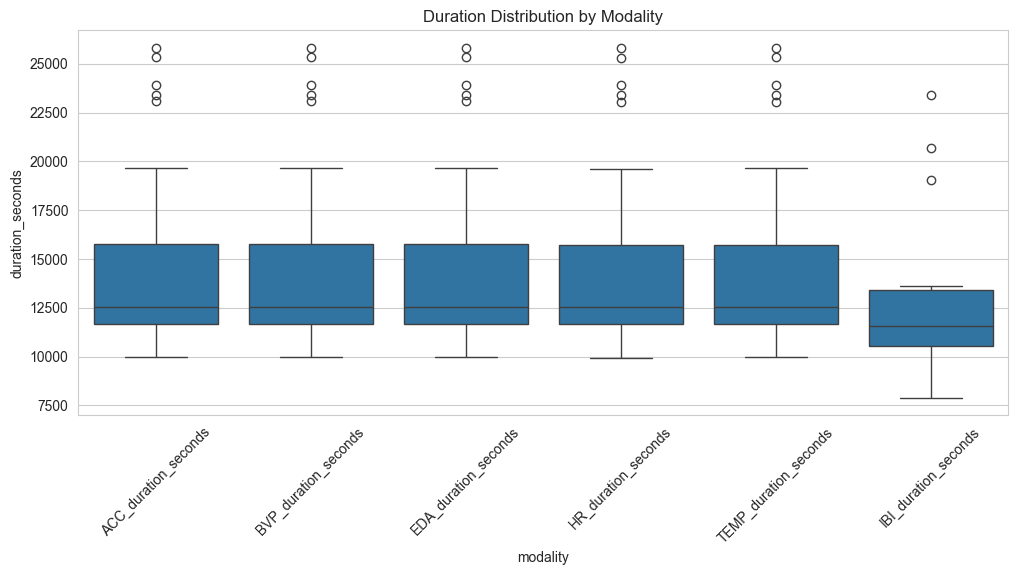

In [72]:
plt.figure(figsize=(12, 5))
duration_plot_df = master_session_df.melt(
    id_vars=["student_id", "exam_folder"],
    value_vars=duration_cols,
    var_name="modality",
    value_name="duration_seconds"
)

sns.boxplot(data=duration_plot_df, x="modality", y="duration_seconds")
plt.xticks(rotation=45)
plt.title("Duration Distribution by Modality")
plt.show()


In [73]:
master_session_df = master_session_df.merge(
    grades_wide_df,
    on="student_id",
    how="left",
    suffixes=("", "_student_level")
)

master_session_df.head()


,student_id,exam_folder,session_path,session_exists,ACC_loaded,ACC_n_samples,ACC_sample_rate,ACC_duration_seconds,ACC_start_timestamp,ACC_end_timestamp,...,tags_duration_seconds,tags_start_timestamp,tags_end_timestamp,tags_error,grade,grade_binary,final,midterm_1,midterm_2,final_binary
0,S1,Final,/Users/parsa/Desktop/projects/github/Attention...,True,True,748686,32.0,23396.40625,1.544027e+09,1.544051e+09,...,NaN,NaN,NaN,None,182.0,1,182.0,78.0,82.0,1
1,S1,Midterm 1,/Users/parsa/Desktop/projects/github/Attention...,True,True,357702,32.0,11178.15625,1.539435e+09,1.539447e+09,...,546.55,1.539446e+09,1.539447e+09,None,78.0,1,182.0,78.0,82.0,1
2,S1,Midterm 2,/Users/parsa/Desktop/projects/github/Attention...,True,True,356376,32.0,11136.71875,1.541860e+09,1.541871e+09,...,NaN,NaN,NaN,None,82.0,1,182.0,78.0,82.0,1
3,S2,Final,/Users/parsa/Desktop/projects/github/Attention...,True,True,810780,32.0,25336.84375,1.544027e+09,1.544053e+09,...,NaN,NaN,NaN,None,180.0,1,180.0,82.0,85.0,1
4,S2,Midterm 1,/Users/parsa/Desktop/projects/github/Attention...,True,True,383496,32.0,11984.21875,1.539435e+09,1.539447e+09,...,1316.85,1.539446e+09,1.539447e+09,None,82.0,1,180.0,82.0,85.0,1


In [74]:
master_session_df.to_csv(OUTPUT_DIR / "master_session_metadata.csv", index=False)
print("Saved:", OUTPUT_DIR / "master_session_metadata.csv")


Saved: /Users/parsa/Desktop/projects/github/Attention-Based-Stress-Prediction-Wearables/outputs/master_session_metadata.csv
